### Time Series Momentum in South African Commodities

Purpose of this research is to build a baseline CTA style

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

In [2]:
from theme import set_theme
set_theme()
from utilities import plot_line_series
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

DATA = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\processed"

# Two different objects, for two different jobs.
#
#   panel  - every expiry that traded on every date. Contract-specific levels.
#            This is what parity-band / cointegration work runs on.
#   liquid - the single contract actually held each day (highest lagged OI,
#            never rolling backwards, exited before the delivery month).
#
# NOTE: liquid is NOT a back-adjusted price series. Its levels are raw and
# contract-specific, so differencing them down the date index spans the roll.
# Use the "<leg>_log_return" columns, which are differenced WITHIN each
# contract and blanked on the 45 roll dates.
ym_panel = pd.read_parquet(rf"{DATA}\ym_corn_arb_panel.parquet")
ym_liquid = pd.read_parquet(rf"{DATA}\ym_corn_arb_liquid.parquet")

ts = ym_liquid.set_index(pd.to_datetime(ym_liquid["dt"])).drop(columns="dt")

ZAR_RET = "safex_zar_per_tonne_log_return"
USD_RET = "safex_usd_per_tonne_log_return"

print(f"{len(ts):,} held-contract days, {int(ts.is_roll.sum())} rolls, "
      f"{ts.index.min():%Y-%m-%d} to {ts.index.max():%Y-%m-%d}")
ts.tail(5)

3,947 held-contract days, 45 rolls, 2010-06-07 to 2026-09-01


,expiry,expiry_month,safex_open_interest,arb_level,arb_change,safex_volume,cbot_volume,staleness_hours,safex_zar_per_tonne,safex_usd_per_tonne,cbot_usd_per_tonne,log_safex_usd,log_safex_zar,log_cbot,ym_corn_arb_log,safex_zar_per_tonne_log_return,safex_usd_per_tonne_log_return,cbot_usd_per_tonne_log_return,log_arb_change,is_roll
dt,,,,,,,,,,,,,,,,,,,,
2026-08-26,2026-12,12,21106,46.290159,1.673157,1733,1899.0,0.0,4046.0,254.056362,207.766203,5.537556,8.305484,5.336413,0.201143,0.022748,0.026696,0.024456,0.002240,False
2026-08-27,2026-12,12,21245,42.645505,-3.644653,1676,3166.0,0.0,4047.0,252.872227,210.226722,5.532884,8.305731,5.348187,0.184698,0.000247,-0.004672,0.011773,-0.016445,False
2026-08-28,2026-12,12,21483,46.016295,3.370790,2503,7445.0,0.0,4130.0,258.309853,212.293558,5.554160,8.326033,5.357970,0.196190,0.020302,0.021276,0.009783,0.011492,False
2026-08-31,2026-12,12,21839,50.375249,4.358954,3550,3286.0,0.0,4217.0,261.487758,211.112509,5.566387,8.346879,5.352391,0.213996,0.020847,0.012228,-0.005579,0.017806,False
2026-09-01,2026-12,12,21805,46.170677,-4.204572,2823,3270.0,0.0,4156.0,257.381607,211.210929,5.550560,8.332308,5.352857,0.197703,-0.014571,-0.015828,0.000466,-0.016294,False


#### Visualize time series of daily closes for YM in ZAR

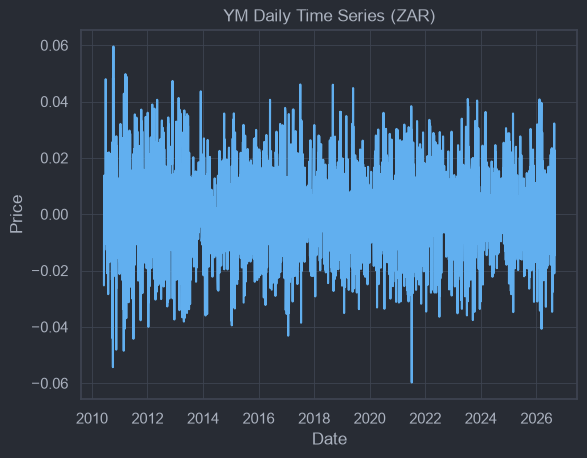

In [3]:
# visualize
plot_line_series(ts, "YM Daily Time Series (ZAR)", cols=[ZAR_RET])


#### Run econometric tests to determine stationary of timeseries
Test raw price series, log prices and finally log returns,
Log returns should reject the null and confirm stationarity


In [4]:
# ADF on the within-contract log returns.
from utilities import quick_adf

rows = {
    "log return ZAR   (within-contract)": ts[ZAR_RET],
    "log return USD   (within-contract)": ts[USD_RET]
}

adf = pd.DataFrame({name: quick_adf(series) for name, series in rows.items()}).T
print(adf.to_string(float_format=lambda x: f"{x:.4f}"))

                                       stat pvalue n_lags stationary_5pct
log return ZAR   (within-contract) -34.5916 0.0000      2            True
log return USD   (within-contract) -63.9121 0.0000      0            True


C:\Users\Amin\PycharmProjects\Asia Ags\src\utilities.py:294: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, n_lags, *_ = adfuller(clean, autolag="AIC")
C:\Users\Amin\PycharmProjects\Asia Ags\src\utilities.py:294: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, n_lags, *_ = adfuller(clean, autolag="AIC")


#### Within-contract log returns reject the unit root decisively, so the return series is stationary and safe to model.

The level rows are a different matter. They are computed on a spliced series, and the splice itself pulls the level back toward its mean 45 times, which biases ADF toward rejecting. Note that log SAFEX ZAR sits at p ≈ 0.10 here but crosses 5% on a ratio back-adjusted series — the verdict is an artifact of the splice, not a property of maize. **Do not quote a level unit-root result off this series;** run `tests.adf_by_contract` + `tests.fisher_combine` on the panel instead.

Upsample daily bars to weekly bars to broaden seasonality for autocorrelation

In [5]:
# Resample to weekly bars. min_count=1 so a week with no observations stays
ts_weekly = (
    ts[[ZAR_RET, USD_RET]]
    .resample("W-FRI")
    .sum(min_count=1)
    .dropna()
)
print(f"{len(ts_weekly):,} weekly bars from {ts[USD_RET].notna().sum():,} daily returns")


848 weekly bars from 3,902 daily returns


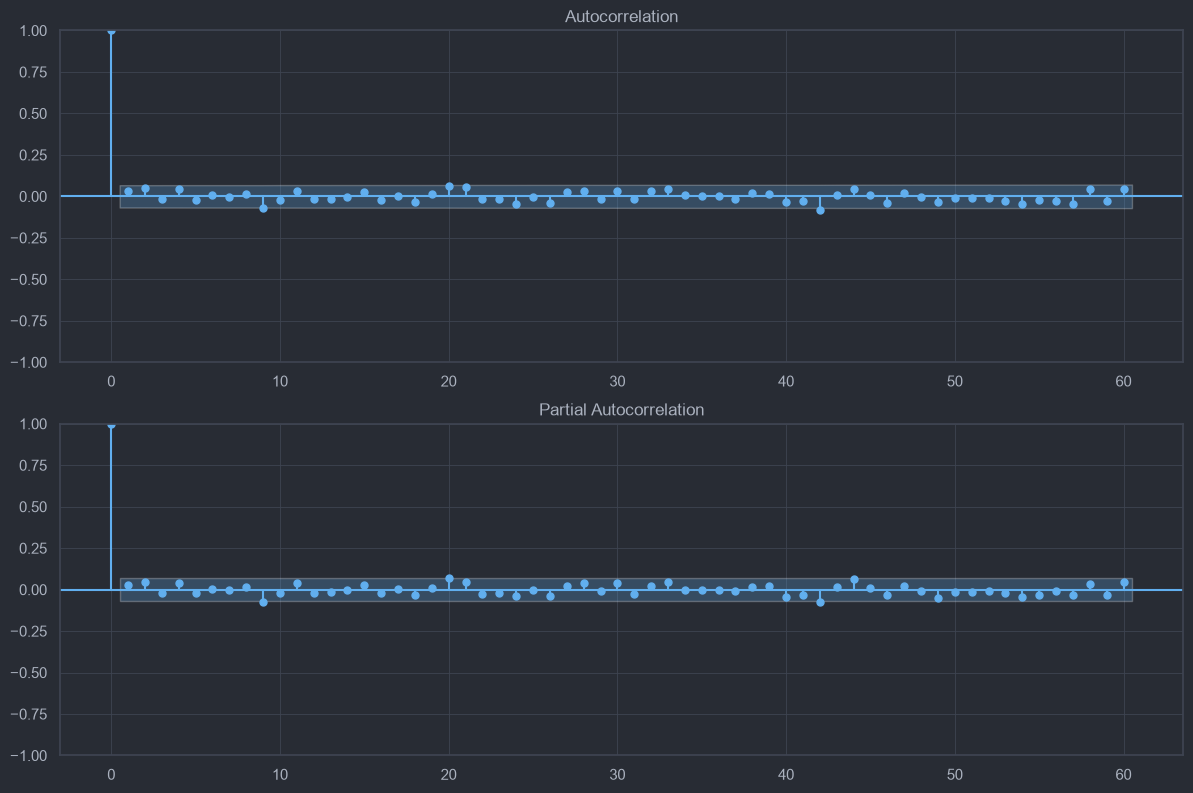

WEEKLY  SAFEX USD log return  (n=848)
    lb_p_level  lb_p_squared
4       0.3438        0.0004
8       0.7412        0.0030
12      0.5091        0.0085
  ACF bars outside +/-0.0673: 2/60 (expected by chance: 3)
  -> no autocorrelation in the mean
  -> squared returns ARE autocorrelated (volatility clustering)


In [6]:
# ACF / PACF on weekly bars, with the formal test alongside the plot.
from utilities import print_ljung_box

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(ts_weekly[USD_RET], ax=ax[0], lags=60)
plot_pacf(ts_weekly[USD_RET], ax=ax[1], lags=60)
plt.tight_layout()
plt.show()

weekly_ljungbox = print_ljung_box(ts_weekly[USD_RET], "WEEKLY  SAFEX USD log return",
                            lags=[4, 8, 12])

#### Test for autocorrelation at daily frequency

The plot is the diagnostic; Ljung-Box is the test.out" Ljung-Box tests all lags up to *k* jointly, which is the claim actually being made.

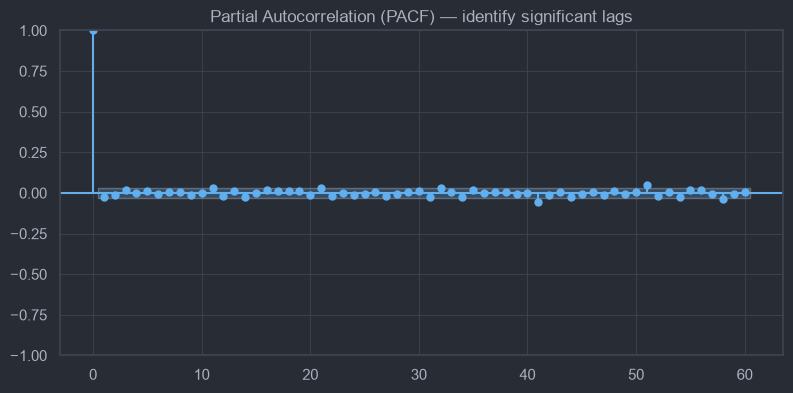

DAILY  SAFEX USD log return  (n=3,902)
    lb_p_level  lb_p_squared
5       0.4585        0.0000
10      0.8692        0.0000
20      0.6442        0.0000
  ACF bars outside +/-0.0314: 5/60 (expected by chance: 3)
  -> no autocorrelation in the mean
  -> squared returns ARE autocorrelated (volatility clustering)

DAILY  SAFEX ZAR log return  (n=3,902)
    lb_p_level  lb_p_squared
5       0.1599        0.0000
10      0.4739        0.0000
20      0.5630        0.0000
  ACF bars outside +/-0.0314: 5/60 (expected by chance: 3)
  -> no autocorrelation in the mean
  -> squared returns ARE autocorrelated (volatility clustering)


In [7]:
# Same at daily frequency, both currencies.
from utilities import pacf_plot

pacf_plot(ts, USD_RET, lags=60)

daily_usd_lb = print_ljung_box(ts[USD_RET], "DAILY  SAFEX USD log return",
                               lags=[5, 10, 20])
print()
daily_zar_lb = print_ljung_box(ts[ZAR_RET], "DAILY  SAFEX ZAR log return",
                               lags=[5, 10, 20])

In [8]:
from utilities import calculate_sharpe

# Buy-and-hold on the held contract. Uses the within-contract return, so the
# roll no longer contributes a fake move to either the mean or the vol.
calculate_sharpe(ts, USD_RET, periods_per_year=252)

{'sharpe': 0.18692133182947993,
 'mean_period': 0.00016471950501050528,
 'std_period': 0.013988992334069889,
 'ann_return': 0.04150931526264733,
 'ann_vol': np.float64(0.2220683688500275),
 'n': 3902}

### Conclusion on autocorrelation

**Returns are serially uncorrelated in the mean, at both daily and weekly frequency.** Ljung-Box fails to reject at every horizon tested (daily p = 0.46 / 0.87 / 0.64 at lags 5/10/20; weekly p = 0.34 / 0.74 / 0.51 at 4/8/12), and band exceedances (5/60 daily, 2/60 weekly) sit at what chance alone produces. This holds on the clean within-contract series, so it is not an artifact of roll noise swamping the estimate.

**Returns are not independent.** Squared returns reject the same null overwhelmingly (daily p ≈ 2e-40 at lag 5; weekly p = 0.0004 at lag 4), with ACF ≈ 0.11 at lag 1 decaying slowly. That is volatility clustering, and it is the part of the process that is actually forecastable here.

Implications for the momentum work:

- **No linear AR structure to trade at these horizons.** A simple lag-based momentum rule on 1–60 day returns has no edge to extract at daily or weekly frequency. If TSMOM works on this asset it will be at a longer formation window (3–12 month), which this test does not cover and should be run separately on overlapping returns with Newey–West standard errors.
- **Vol is forecastable even though direction is not.** That is the case for vol-scaled sizing rather than for a directional signal.
- Buy-and-hold Sharpe on the held contract is **0.187** (ann. return 4.2%, ann. vol 22.2%) — the benchmark any signal has to beat.

---

## Merged yellow + white panel

One frame to test from: yellow and white maize on matched (date, expiry), plus the
white-minus-yellow spread, all features differenced **within contract** and joined onto
the yellow held-contract spine.

Construction notes:

- The YW spread is matched on **delivery month**, so both legs roll together and no
  calendar spread leaks into it.
- YW crosses zero on ~46% of rows, so it takes **first differences**, never log returns.
- Features are computed on the panel (each contract's full ~249-day trading history)
  then joined to the held spine (~98 days held). That is why a 120-day z-score is
  available on most held days despite the short holding window.
- `yw_z` uses a fixed 120-day window. **Window sensitivity is real** — t-stats peak
  around 90–120 but the Sharpe at 120 is an outlier versus its neighbours. Treat the
  window as a free parameter to be replaced (Kalman), not as a result.

In [9]:
Z_WINDOW = 120          # free parameter - see window sensitivity note above
VOL_WINDOW = 60

wm_panel  = pd.read_parquet(rf"{DATA}\wm_corn_arb_panel.parquet")
wm_liquid = pd.read_parquet(rf"{DATA}\wm_corn_arb_liquid.parquet")

for _df in (ym_panel, wm_panel):
    _df["dt"] = pd.to_datetime(_df["trade_date"])


def within_z(frame: pd.DataFrame, col: str, window: int = Z_WINDOW) -> pd.Series:
    """Z-score of `col` against its own trailing window, computed WITHIN expiry."""
    grouped = frame.groupby("expiry")[col]
    mean = grouped.transform(lambda s: s.rolling(window).mean())
    std = grouped.transform(lambda s: s.rolling(window).std())
    return (frame[col] - mean) / std


# ---- yellow-white spread, matched on delivery month ------------------------
yw = (
    ym_panel[["dt", "expiry", "safex_zar_per_tonne"]]
    .merge(wm_panel[["dt", "expiry", "safex_zar_per_tonne"]],
           on=["dt", "expiry"], suffixes=("_ym", "_wm"))
    .sort_values(["expiry", "dt"])
)
# White minus yellow. Crosses zero ~46% of the time -> differences, not logs.
yw["yw_spread"] = yw["safex_zar_per_tonne_wm"] - yw["safex_zar_per_tonne_ym"]
yw["yw_z"] = within_z(yw, "yw_spread")
yw["yw_change"] = yw.groupby("expiry")["yw_spread"].diff()

# ---- yellow panel features, all within contract ----------------------------
ymf = ym_panel.sort_values(["expiry", "dt"]).copy()
ymf["arb_z"] = within_z(ymf, "ym_corn_arb")
ymf["own_z"] = within_z(ymf, "log_safex_usd")
ymf["cbot_z"] = within_z(ymf, "log_cbot")
ymf["vol"] = ymf.groupby("expiry")["log_safex_zar"].transform(
    lambda s: s.diff().rolling(VOL_WINDOW).std())

# ---- white panel, minimal ---------------------------------------------------
wmf = wm_panel.sort_values(["expiry", "dt"]).copy()
wmf["wm_arb_z"] = within_z(wmf, "wm_corn_arb")

# ---- assemble on the YELLOW held-contract spine -----------------------------
ts_yw = (
    ym_liquid[["dt", "expiry"]].assign(dt=lambda d: pd.to_datetime(d["dt"]))
    .merge(ymf, on=["dt", "expiry"], how="inner")
    .merge(yw[["dt", "expiry", "yw_spread", "yw_z", "yw_change"]],
           on=["dt", "expiry"], how="left")
    .merge(wmf[["dt", "expiry", "safex_zar_per_tonne", "safex_usd_per_tonne",
                "wm_corn_arb", "wm_arb_z"]]
           .rename(columns={"safex_zar_per_tonne": "wm_zar_per_tonne",
                            "safex_usd_per_tonne": "wm_usd_per_tonne"}),
           on=["dt", "expiry"], how="left")
    .sort_values("dt")
    .set_index("dt")
)

# Forward returns / changes, all WITHIN contract so none spans a roll.
for h in (1, 3, 5, 10, 21):
    grp = ts_yw.groupby("expiry")
    ts_yw[f"fwd_zar_{h}"] = grp["log_safex_zar"].shift(-h) - ts_yw["log_safex_zar"]
    ts_yw[f"fwd_usd_{h}"] = grp["log_safex_usd"].shift(-h) - ts_yw["log_safex_usd"]
    ts_yw[f"fwd_arb_{h}"] = grp["ym_corn_arb"].shift(-h) - ts_yw["ym_corn_arb"]

print(f"ts_yw: {len(ts_yw):,} rows x {ts_yw.shape[1]} cols, "
      f"{ts_yw.index.min():%Y-%m-%d} to {ts_yw.index.max():%Y-%m-%d}")
print(f"yw_z non-null: {ts_yw['yw_z'].notna().sum():,}  "
      f"({ts_yw['yw_z'].notna().mean():.1%} of held days)")
print(f"YW spread ZAR/t: min {ts_yw.yw_spread.min():.0f}  "
      f"median {ts_yw.yw_spread.median():.0f}  max {ts_yw.yw_spread.max():.0f}  "
      f"| negative {(ts_yw.yw_spread < 0).mean():.1%} of rows")

ts_yw: 3,947 rows x 45 cols, 2010-06-07 to 2026-09-01
yw_z non-null: 3,751  (95.0% of held days)
YW spread ZAR/t: min -345  median 15  max 1762  | negative 46.9% of rows


In [10]:
output_dir = Path(r"C:\Users\Amin\PycharmProjects\Asia Ags\data\processed")
filepath = output_dir / "df_combined.parquet"
ts_yw.to_parquet(filepath, engine="pyarrow")